In [6]:
import sys
!{sys.executable} -m pip install torch transformers datasets tqdm matplotlib

  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 5.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   ----- ---------------------------------- 3.7/27.6 MB 19.8 MB/s eta 0:00:02
   --------- ------------------------------ 6.6/27.6 MB 16.8 MB/s eta 0:00:02
   ------------- -------------------------- 9.4/27.6 MB 15.4 MB/s eta 0:00:02
   ----------------- ---------------------- 12.3/27.6 MB 14.9 MB/s eta 0:00:02
   ---------------------- ----------------- 15.2/27.6 MB 14.7 MB/s eta 0:00:01
   -------------------------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pathlib import Path
import math

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm

c:\Users\Sena\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", device)

model_name = "gpt2"
local_model_dir = Path("models") / model_name

Устройство: cuda


In [7]:
def load_model_and_tokenizer(model_name, local_dir, device="cpu"):
    local_dir.mkdir(parents=True, exist_ok=True)

    # если модель уже есть в папке, грузим локально
    if (local_dir / "config.json").exists():
        print(f"Загружаю модель из локальной папки: {local_dir}")

        tokenizer = AutoTokenizer.from_pretrained(
            local_dir,
            local_files_only=True
        )

        model = AutoModelForCausalLM.from_pretrained(
            local_dir,
            local_files_only=True
        ).to(device)

    else:
        print("Локальная копия не найдена, скачиваю модель...")

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

        print(f"Сохраняю модель в папку: {local_dir}")
        tokenizer.save_pretrained(local_dir)
        model.save_pretrained(local_dir)

    model.eval()
    return tokenizer, model

In [8]:
tokenizer, model_fp32 = load_model_and_tokenizer(
    model_name=model_name,
    local_dir=local_model_dir,
    device=device
)

print("Модель и токенизатор готовы")

Локальная копия не найдена, скачиваю модель...


c:\Users\Sena\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sena\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10866.64it/s]


Сохраняю модель в папку: models\gpt2


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.22it/s]

Модель и токенизатор готовы


In [9]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [10]:
def naive_quantize_tensor(tensor):
    max_val = tensor.abs().max()

    # защита от деления на ноль
    if max_val == 0:
        return tensor.clone()

    scale = max_val / 127
    q_tensor = torch.round(tensor / scale).clamp(-128, 127)

    # возвращаем обратно в float после квантизации
    dequantized_tensor = q_tensor * scale
    return dequantized_tensor

In [11]:
model_int8 = AutoModelForCausalLM.from_pretrained(local_model_dir).to(device)

with torch.no_grad():
    for name, param in model_int8.named_parameters():
        param.copy_(naive_quantize_tensor(param))

model_int8.eval()

print("INT8-версия модели подготовлена")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9841.73it/s]


INT8-версия модели подготовлена


In [15]:


data_dir = Path("data") / "wikitext"
data_dir.mkdir(parents=True, exist_ok=True)

dataset = load_dataset(
    "wikitext",
    "wikitext-2-raw-v1",
    cache_dir=data_dir
)

texts = dataset["test"]["text"]
texts = [text for text in texts if text.strip() != ""]

print("Количество непустых текстов:", len(texts))
print()
print("Пример текста:")
print(texts[0][:500])

Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 940068.14 examples/s]

Количество непустых текстов: 2891

Пример текста:
 = Robert Boulter = 



In [16]:
def compute_perplexity(model, texts, tokenizer, max_samples=200):
    total_loss = 0.0
    total_tokens = 0

    for text in tqdm(texts[:max_samples]):
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        input_ids = enc["input_ids"].to(device)

        # слишком короткие последовательности пропускаем
        if input_ids.size(1) < 2:
            continue

        with torch.no_grad():
            outputs = model(input_ids, labels=input_ids)
            loss = outputs.loss

        n_tokens = input_ids.size(1)
        total_loss += loss.item() * n_tokens
        total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)

    return ppl

In [17]:
ppl_fp32 = compute_perplexity(model_fp32, texts, tokenizer, max_samples=200)
ppl_int8 = compute_perplexity(model_int8, texts, tokenizer, max_samples=200)

print("Perplexity FP32:", round(ppl_fp32, 4))
print("Perplexity INT8:", round(ppl_int8, 4))

100%|██████████| 200/200 [00:02<00:00, 99.92it/s] 

Perplexity FP32: 50.3304
Perplexity INT8: 61.232


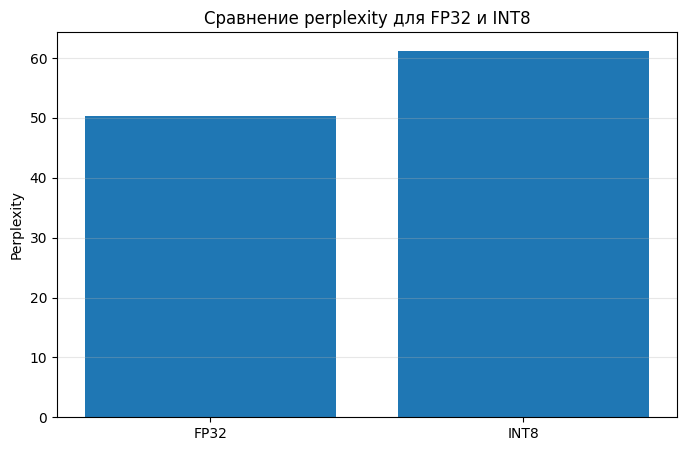

In [21]:
models = ["FP32", "INT8"]
ppl_values = [ppl_fp32, ppl_int8]

plt.figure(figsize=(8, 5))
plt.bar(models, ppl_values)
plt.ylabel("Perplexity")
plt.title("Сравнение perplexity для FP32 и INT8")
plt.grid(axis="y", alpha=0.3)
plt.show()

После наивной квантизации модели GPT-2 из FP32 в INT8 значение perplexity на датасете WikiText-2 увеличилось с 50.33 до 61.23.
Это означает, что качество предсказания текста ухудшилось.
Рост perplexity обозначает что наивнаая квантизация дает заметные искажения

In [18]:
def compute_kl_per_sample(model_fp32, model_int8, texts, tokenizer, max_samples=100):
    kl_values = []

    for text in tqdm(texts[:max_samples]):
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=256
        )

        input_ids = enc["input_ids"].to(device)

        if input_ids.size(1) < 2:
            continue

        with torch.no_grad():
            logits_fp32 = model_fp32(input_ids).logits
            logits_int8 = model_int8(input_ids).logits

        log_p = F.log_softmax(logits_fp32, dim=-1)
        q = F.softmax(logits_int8, dim=-1)

        kl = F.kl_div(log_p, q, reduction="batchmean")
        kl_values.append(kl.item())

    return kl_values

In [19]:
kl_values = compute_kl_per_sample(
    model_fp32,
    model_int8,
    texts,
    tokenizer,
    max_samples=100
)

kl_mean = sum(kl_values) / len(kl_values)

print("Средний KL(FP32 || INT8):", round(kl_mean, 6))

100%|██████████| 100/100 [00:01<00:00, 54.90it/s]

Средний KL(FP32 || INT8): 20.593955


Посмотрим что выводится

In [33]:
def generate_text(model, tokenizer, prompt, max_length=100):
    model.eval()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=max_length,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.9
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated_text

In [37]:
prompts = [
    "Machine learning is",
    "The theory of relativity",
    "In recent years, artificial intelligence",
    "The history of the Roman Empire"
]

for prompt in prompts:
    print("\n" + "="*100)
    print("PROMPT:", prompt)

    text_fp32 = generate_text(model_fp32, tokenizer, prompt)
    text_int8 = generate_text(model_int8, tokenizer, prompt)

    print("\nFP32:")
    print(text_fp32[len(prompt):])

    print("\nINT8:")
    print(text_int8[len(prompt):])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



PROMPT: Machine learning is


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



FP32:
 not only about learning, it is also about learning about the world. In fact, it is about learning about the world.

The most interesting thing about this new paradigm is that it is about the world.

And, as you can see, it is about learning about the world.

There are two major things that the world needs to learn about. One is that the world needs to learn about how to be better at it. The other is that the world

INT8:
 one of the biggest challenges in the field of artificial intelligence. This article will show how to build a prototype robot that will be able to recognize objects that are moving at high speeds and recognize objects that are moving at low speeds. We'll also talk about how to create a prototype robot that will recognize objects that are moving at high speeds and recognize objects that are moving at low speeds.

This article will show how to build a prototype robot that will recognize objects that are moving at high

PROMPT: The theory of relativity


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



FP32:
 was developed by Einstein's first major experiment, the second, which involved measuring the speed of light in the universe. The theory of relativity was developed by Einstein's first major experiment, the second, which involved measuring the speed of light in the universe.

The following is a short description of the various physics of light.

The first term in this term is the Einstein-Einstein equation, which describes the basic physics of light. The term Einstein-Einstein equation

INT8:
 has been studied by many scholars, but it is not an exact science. It is a theory of things that cannot be observed.

The theory of relativity does not say that everything is consistent. It says that everything is consistent. But what is consistent is not the consistency of anything. It is the consistency of everything.

The theory of relativity has a very simple explanation of how things can be consistent. It is based on principles that are not necessarily true. The theory

PROMPT: In rec

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



FP32:
 has become a powerful tool for developing new techniques and technologies to understand human behavior.

For example, artificial intelligence can be used to predict the behavior of animals, to predict when they will eat a certain food, to predict how much a certain person will eat a certain food, to predict how much a certain person will eat a certain food, to predict how much a certain person will eat a certain food, to predict how much a certain person will eat a certain food

INT8:
 has become a prominent contender for the next frontier in the field of robotics. While it can't be definitively ruled out, it's already a reality.

There's no doubt that artificial intelligence is poised to become the next frontier in robotics. And if it continues to dominate the field, that could cause significant disruption to the world of robotics.

As a result, artificial intelligence has been viewed as a threat to human life, including our own.

Human

PROMPT: The history of the Roman Empire

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



FP32:
 is littered with these tales. The Emperor Augustus, for example, was a Roman Catholic. The Roman Catholic Church, however, was a Protestant denomination. The Church of Rome, however, was a Roman Catholic Church. The Church of Rome was a Roman Catholic Church. The Church of Rome was a Roman Catholic Church.

And so it's not just the Church of Rome that was a Roman Catholic. The Catholic Church was also a Roman Catholic Church. The Catholic Church

INT8:
 dates back to the eighth century CE, and the reign of Emperor Nero, who took office in 1551. In his reign, Nero took full control of the empire, and in 1554 he set up the first state of Roman rule in Europe. He ruled for three years, but when the Roman Empire fell into civil war in 1559, he decided to take over. In 1561, he seized control of the capital city of Rome and the city of Trajan


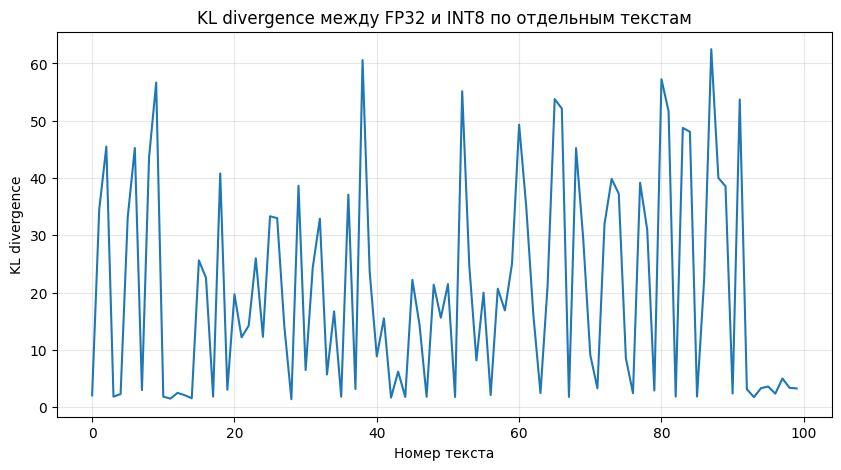

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(kl_values)
plt.xlabel("Номер текста")
plt.ylabel("KL divergence")
plt.title("KL divergence между FP32 и INT8 по отдельным текстам")
plt.grid(alpha=0.3)
plt.show()

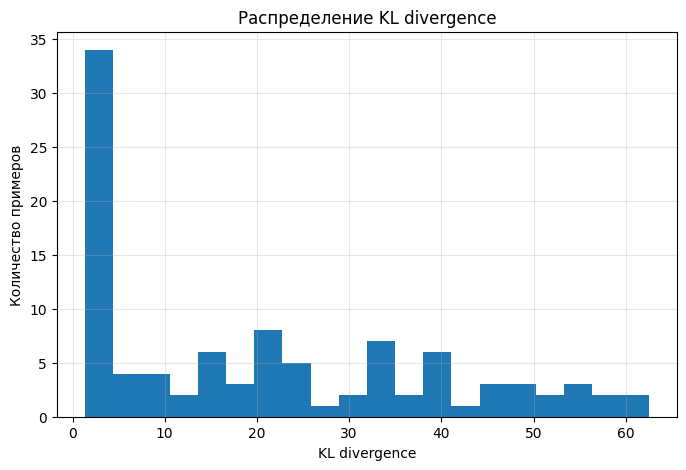

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(kl_values, bins=20)
plt.xlabel("KL divergence")
plt.ylabel("Количество примеров")
plt.title("Распределение KL divergence")
plt.grid(alpha=0.3)
plt.show()

In [24]:
print("=== Итоги эксперимента ===")
print(f"Perplexity FP32: {ppl_fp32:.4f}")
print(f"Perplexity INT8: {ppl_int8:.4f}")
print(f"Средний KL(FP32 || INT8): {kl_mean:.6f}")

=== Итоги эксперимента ===
Perplexity FP32: 50.3304
Perplexity INT8: 61.2320
Средний KL(FP32 || INT8): 20.593955


Посмотрим на каких текстах ломается KL

In [25]:
def compute_kl_with_texts(model_fp32, model_int8, texts, tokenizer, max_samples=100):
    results = []

    for i, text in enumerate(tqdm(texts[:max_samples])):
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=256
        )

        input_ids = enc["input_ids"].to(device)

        if input_ids.size(1) < 2:
            continue

        with torch.no_grad():
            logits_fp32 = model_fp32(input_ids).logits
            logits_int8 = model_int8(input_ids).logits

        log_p = F.log_softmax(logits_fp32, dim=-1)
        q = F.softmax(logits_int8, dim=-1)

        kl = F.kl_div(log_p, q, reduction="batchmean").item()

        results.append({
            "index": i,
            "text": text,
            "kl": kl,
            "length": input_ids.size(1)
        })

    return results

In [26]:
kl_results = compute_kl_with_texts(
    model_fp32,
    model_int8,
    texts,
    tokenizer,
    max_samples=100
)

print("Количество обработанных текстов:", len(kl_results))

100%|██████████| 100/100 [00:01<00:00, 54.38it/s]

Количество обработанных текстов: 100


In [27]:
top_bad = sorted(kl_results, key=lambda x: x["kl"], reverse=True)[:10]

for item in top_bad:
    print("=" * 100)
    print(f"Индекс текста: {item['index']}")
    print(f"KL divergence: {item['kl']:.4f}")
    print(f"Длина в токенах: {item['length']}")
    print("Текст:")
    print(item["text"][:1000])
    print()

Индекс текста: 87
KL divergence: 62.4893
Длина в токенах: 201
Текст:
 Shot by November 2012 , the music video was characterised , in several MTV News interviews , as " bigger than anything we 've done before " by Zayn Malik , as " a lot of hard work " by Payne , as " pure stupidity " by Louis Tomlinson , and as " I wouldn 't say [ it 's ] comedy , it 's all tongue @-@ in @-@ cheek " by Arnell . Premiering worldwide on Vevo on 7 January 2013 , the music video depicts the band shooting different scenes via a green screen , dressed as sailors , surfers , skiers and jailers . The video features scenes reminiscent of the films South Pacific , To Catch a Thief , Jailhouse Rock and Beach Blanket Bingo , as well as the iconic music videos of songs such as The Beach Boys ' " Surfer Girl " , Elvis Presley 's " Blue Hawaii " and Rammstein 's " Mein Land " , among others . 


Индекс текста: 38
KL divergence: 60.6020
Длина в токенах: 183
Текст:
 Luoyang , the region of his birthplace , was recovere

In [28]:
top_good = sorted(kl_results, key=lambda x: x["kl"])[:10]

for item in top_good:
    print("=" * 100)
    print(f"Индекс текста: {item['index']}")
    print(f"KL divergence: {item['kl']:.4f}")
    print(f"Длина в токенах: {item['length']}")
    print("Текст:")
    print(item["text"][:1000])
    print()

Индекс текста: 28
KL divergence: 1.3641
Длина в токенах: 9
Текст:
 = = = War = = = 


Индекс текста: 11
KL divergence: 1.4681
Длина в токенах: 9
Текст:
 = = = Film = = = 


Индекс текста: 14
KL divergence: 1.5295
Длина в токенах: 6
Текст:
 = Du Fu = 


Индекс текста: 42
KL divergence: 1.6373
Длина в токенах: 7
Текст:
 = = Works = = 


Индекс текста: 93
KL divergence: 1.7334
Длина в токенах: 4
Текст:
 CD single 


Индекс текста: 51
KL divergence: 1.7522
Длина в токенах: 10
Текст:
 = = = Technical excellence = = = 


Индекс текста: 44
KL divergence: 1.7619
Длина в токенах: 9
Текст:
 = = = History = = = 


Индекс текста: 67
KL divergence: 1.7718
Длина в токенах: 7
Текст:
 = = Translation = = 


Индекс текста: 47
KL divergence: 1.7876
Длина в токенах: 10
Текст:
 = = = Moral engagement = = = 


Индекс текста: 35
KL divergence: 1.8065
Длина в токенах: 10
Текст:
 = = = Chengdu = = = 




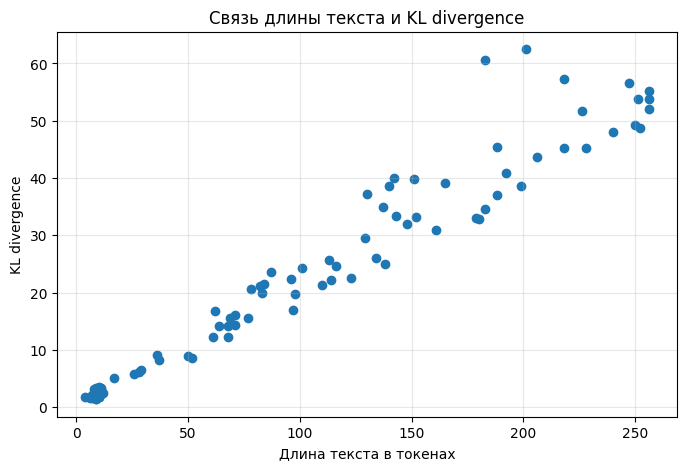

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(df_kl["length"], df_kl["kl"])
plt.xlabel("Длина текста в токенах")
plt.ylabel("KL divergence")
plt.title("Связь длины текста и KL divergence")
plt.grid(alpha=0.3)
plt.show()

По сути видно что чем длиннее текст тем больше накопление ошибки

In [32]:
import numpy as np

corr = np.corrcoef(df_kl["length"], df_kl["kl"])[0, 1]
print("Корреляция:", corr)

Корреляция: 0.9742549800241735


Это коэфф кор Пирсона, показывает насколько сильно связаны величины, [0, 1]